# Практическое занятие: Сравнение подходов Bag-of-Words (CountVectorizer) и TF-IDF

Этот ноутбук наглядно демонстрирует разницу между простым подсчетом частоты слов (**Bag-of-Words**) и взвешенным представлением (**TF-IDF**).

### Главное отличие:
- **Bag-of-Words (BoW)**: Просто считает, сколько раз слово встретилось в тексте. Популярные во всех документах слова (например, предлоги или общие термины) получают самый большой вес.
- **TF-IDF**: Штрафует слова, которые часто встречаются *во всех* документах корпуса, и выделяет уникальные слова, отражающие специфику конкретного текста.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

%matplotlib inline
sns.set_theme(style="whitegrid")

## Подготовка текстового корпуса
Создадим корпус, где явно видны общие слова (клише) и уникальные маркеры тем.

In [3]:
documents = [
    'этот фильм просто отличный и замечательный фильм',
    'фильм был скучный и этот фильм мне не понравился',
    'книга просто отличная и сюжет книги замечательный',
    'скучный сюжет и скучная книга мне не понравилась'
]

for i, doc in enumerate(documents):
    print(f'Документ {i+1}: "{doc}"')

Документ 1: "этот фильм просто отличный и замечательный фильм"
Документ 2: "фильм был скучный и этот фильм мне не понравился"
Документ 3: "книга просто отличная и сюжет книги замечательный"
Документ 4: "скучный сюжет и скучная книга мне не понравилась"


## Расчет матриц BoW и TF-IDF

In [4]:
# Инициализируем векторизаторы
bow_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

# Трансформируем корпус
bow_matrix = bow_vectorizer.fit_transform(documents)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Получаем списки слов
bow_features = bow_vectorizer.get_feature_names_out()
tfidf_features = tfidf_vectorizer.get_feature_names_out()

# Создаем DataFrame для удобной работы
df_bow = pd.DataFrame(bow_matrix.toarray(), columns=bow_features, index=[f'Док {i+1}' for i in range(len(documents))])
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_features, index=[f'Док {i+1}' for i in range(len(documents))])

## Сравнительная визуализация
Построим две тепловые карты рядом, чтобы наглядно увидеть, как меняются веса одинаковых слов.

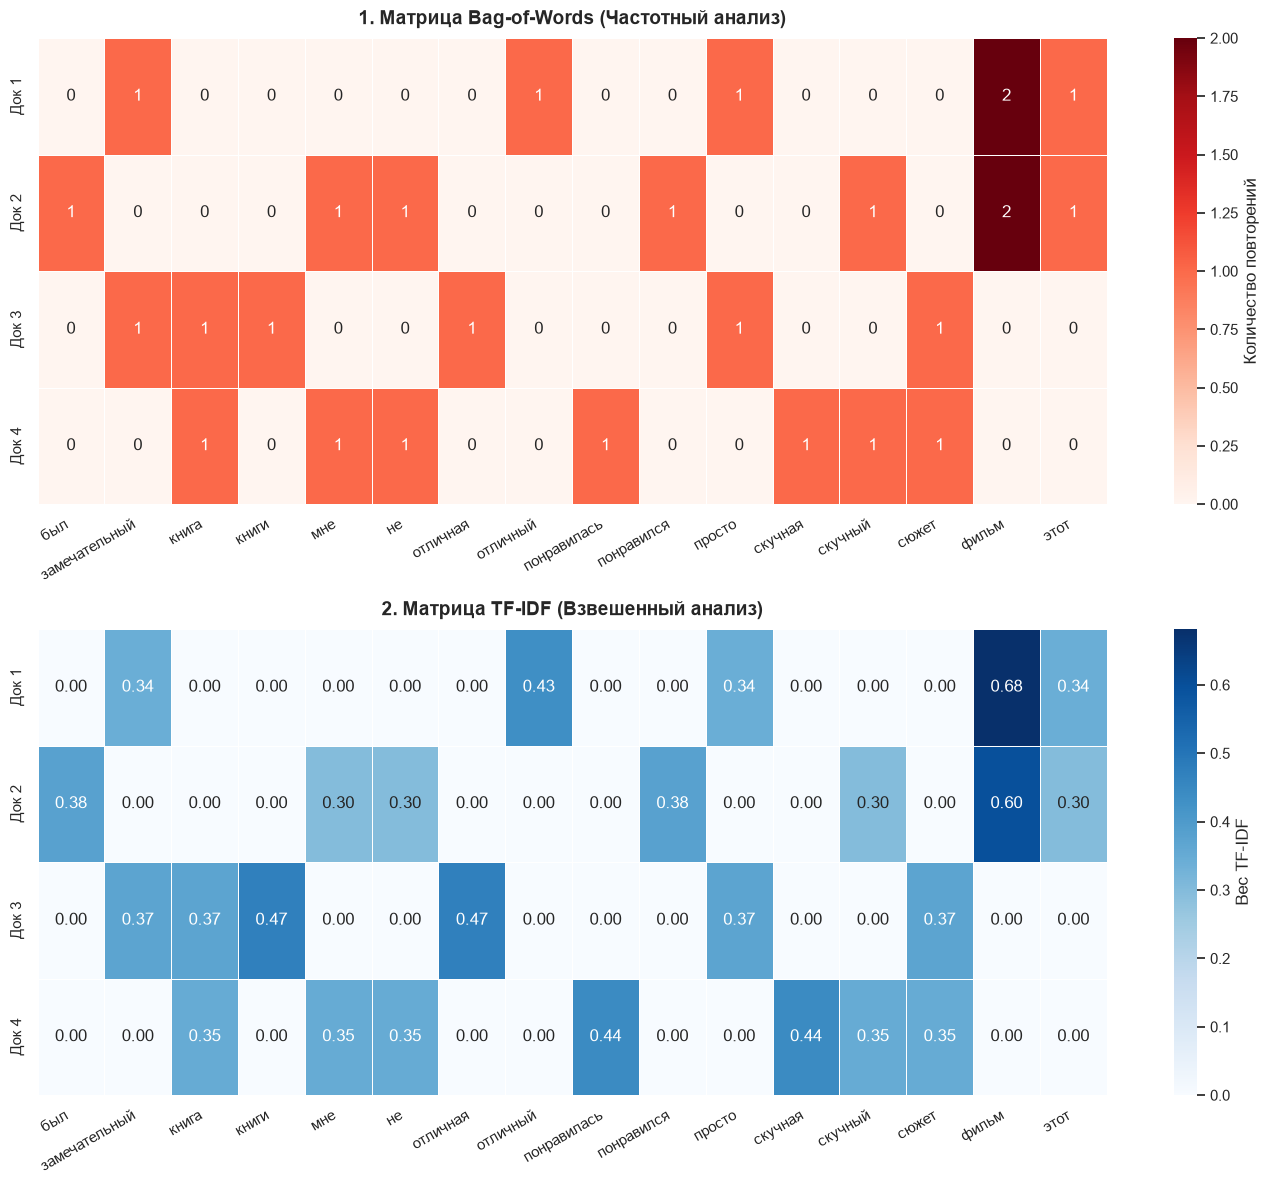

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Тепловая карта для Bag-of-Words
sns.heatmap(
    df_bow, 
    annot=True, 
    fmt="d", 
    cmap="Reds", 
    linewidths=0.5, 
    ax=axes[0],
    cbar_kws={'label': 'Количество повторений'}
)
axes[0].set_title('1. Матрица Bag-of-Words (Частотный анализ)', fontsize=14, weight='bold', pad=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# 2. Тепловая карта для TF-IDF
sns.heatmap(
    df_tfidf, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    linewidths=0.5, 
    ax=axes[1],
    cbar_kws={'label': 'Вес TF-IDF'}
)
axes[1].set_title('2. Матрица TF-IDF (Взвешенный анализ)', fontsize=14, weight='bold', pad=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## Разбор ключевых отличий на графиках

1. **Слово "фильм"**:
   - В **BoW** в Документе 1 оно имеет максимальный вес `2`, так как повторилось дважды. 
   - В **TF-IDF** его вес падает, потому что слово "фильм" встречается еще и в Документе 2. Алгоритм понимает, что это частое слово для данного контекста, и снижает его значимость.

2. **Слово "этот"**:
   - В **BoW** оно имеет одинаковую ценность со всеми остальными словами (`1`).
   - В **TF-IDF** его вес минимален, так как это шумовое слово-союз, не несущее уникального смысла для конкретного текста.

3. **Уникальные маркеры ("замечательный", "отличный")**:
   - В **TF-IDF** именно эти яркие контентные слова получают наибольший вес в тех документах, где они появились, помогая классификаторам лучше понимать разницу между текстами.